In [1]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from gait_cycle_cut import OnlineGaitSegmenter

In [2]:
from scipy.interpolate import interp1d
# resample target
def resample_cycle(cycle, num_points):
	"""Resamples a gait cycle to have a fixed number of points using interpolation."""
	original_indices = np.linspace(0, 1, len(cycle))  # original indices based on the length of the cycle
	new_indices = np.linspace(0, 1, num_points)  # new indices to match the desired number of points
	interpolation_function = interp1d(original_indices, cycle, kind='linear')  # interpolate the data
	return interpolation_function(new_indices)  # return the resampled cycle

In [3]:
def read_json_from_ros2bag(json_file, print_ = False):
	list_of_length = []
	with open(json_file, 'r') as file:
		json_content = json.load(file)
	if print_:
		print('Read: ',json_file)
	for key, value in json_content.items():
		if print_:
			print(f"{key} range: {len(value)}")
		list_of_length.append(len(value))
	cut_data = {key: value[:min(list_of_length)] for key, value in json_content.items()}
	cut_df = pd.DataFrame(cut_data)
	return cut_df


def read_and_normalize_json_from_ros2bag(json_file, print_=False):
	list_of_length = []
	with open(json_file, 'r') as f:
		data = json.load(f)
	if print_:
		print('Read: ',json_file)
	for key, value in data.items():
		if print_:
			print(f"{key} range: {len(value)}")
		list_of_length.append(len(value))
	# Normalize the data into a DataFrame
	df = pd.json_normalize(data)
	return df

def remove_specific_cycles(data_loader, indices_to_remove):
	"""
	Excludes specific indices from every key in the dataset.
	indices_to_remove: list of integers (e.g., [1, 3, 6])
	"""
	cleaned_data = {}
	
	for key in data_loader.files:
		original_list = list(data_loader[key])
		# Keep only the items whose index is NOT in our 'remove' list
		cleaned_data[key] = [
			cycle for i, cycle in enumerate(original_list) 
			if i not in indices_to_remove
		]
		
	return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
	"""
	Interpolates cycles for a specific leg/parameter and calculates mean/std.
	"""
	key = f'{param_prefix}_{leg}'
	if key not in data_source:
		return None, None, None

	raw_cycles = data_source[key]
	normalized_list = []
	

	for j, cycle in enumerate(raw_cycles):
			
		x_old = np.linspace(0, 100, len(cycle))
		x_new = np.linspace(0, 100, norm_points)
		norm_cycle = np.interp(x_new, x_old, cycle)
		normalized_list.append(norm_cycle)
	
	if not normalized_list:
		return None, None, None

	norm_matrix = np.array(normalized_list)
	mean_vals = np.mean(norm_matrix, axis=0)
	std_vals = np.std(norm_matrix, axis=0)
	x_axis = np.linspace(0, 100, norm_points)

	return x_axis, mean_vals, std_vals

def process_sensor_data(input_df, sensor_key, output_column, window_slide=1, shift=0):
	sensor_val = []
	sensor_ts = []
	sensor_df = []

	for i in range(len(input_df[sensor_key][0])):
		sensor_val.append(input_df[sensor_key][0][i]['val'])
		sensor_ts.append(input_df[sensor_key][0][i]['ts'])

	sensor_df = pd.DataFrame(sensor_val, columns=output_column)
	sensor_df = sensor_df.shift(shift)
	sensor_df = sensor_df.rolling(window=window_slide).mean()
	sensor_df['ts'] = sensor_ts

	return sensor_df

In [4]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4', 
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4', 
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4', 
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

In [5]:


# def batch_process_terrain_data(terrains, sensors_config, num_trials=3):
# 	"""
# 	Automates the loading and processing of sensor data across multiple terrains and trials.
# 	"""
# 	all_processed_data = {}

# 	for terrain in terrains:
# 		all_processed_data[terrain] = {}
# 		file_name = f"rosbags/{terrain}_0.json"
# 		print(f"Processing: {file_name}")
# 		raw_df = read_and_normalize_json_from_ros2bag(file_name)
		
# 		trial_results = {}
		
# 		# 2. Process each sensor type defined in the config
# 		for sensor_name, mapping in sensors_config.items():
# 			trial_results[sensor_name] = process_sensor_data(
# 				raw_df, 
# 				mapping['topic'], 
# 				mapping['names'], 
# 				window_slide, 
# 				shift
# 			)
		
# 		all_processed_data[terrain] = trial_results
		
# 	return all_processed_data
import pandas as pd
import glob

def batch_process_terrain_data(terrains, sensors_config):
    """
    Automates loading and processing sensor data. Automatically scans the 'rosbags' 
    directory and merges ALL available gaits into a single DataFrame per sensor.
    """
    all_processed_data = {}

    for terrain in terrains:
        # Temporary storage to hold the DataFrames from each file before we stitch them
        temp_sensor_storage = {sensor: [] for sensor in sensors_config.keys()}
        
        search_pattern = f"rosbags/*_gait_on_{terrain}_*.json"
        matching_files = glob.glob(search_pattern)
        matching_files.sort()
        
        if not matching_files:
            print(f"⚠️ No files found for terrain: {terrain}")
            continue
            
        for file_name in matching_files:
            print(f"Processing: {file_name}")
            
            try:
                raw_df = read_and_normalize_json_from_ros2bag(file_name)
                
                # Process each sensor type defined in the config
                for sensor_name, mapping in sensors_config.items():
                    extracted_df = process_sensor_data(
                        raw_df, 
                        mapping['topic'], 
                        mapping['names'], 
                        window_slide, 
                        shift         
                    )
                    
                    # Store the DataFrame in our temporary list
                    temp_sensor_storage[sensor_name].append(extracted_df)
                    
            except Exception as e:
                print(f"  -> ❌ Error processing {file_name}: {e}")
                
        # ==========================================
        # THE FIX: STITCH THE DATAFRAMES TOGETHER
        # ==========================================
        # This makes the final output structure exactly identical to your old code!
        trial_results = {}
        for sensor_name in sensors_config.keys():
            if len(temp_sensor_storage[sensor_name]) > 0:
                # Combine all files into one giant Pandas DataFrame
                trial_results[sensor_name] = pd.concat(temp_sensor_storage[sensor_name], ignore_index=True)
            else:
                trial_results[sensor_name] = None
                
        # Assign the final stitched data back to the terrain dictionary
        all_processed_data[terrain] = trial_results
        
        print(f"✅ Finished {terrain}: Merged {len(matching_files)} files into one dataset.\n")
        
    return all_processed_data

# --- Configuration ---
shift = 0
window_slide = 1

# List of terrains to iterate through
terrain_types = ['solid_ground', 'soft_ground', 'slippery_ground', 'rough_ground', 'muddy_ground', 'water_surface']

# Define which sensors use name_legs vs name_joints
sensors_to_process = {
	'cpg_output':          				{'topic': 'cpg_ref',            'names': name_joints},
	'foot_force':          				{'topic': 'foot_force_feedback',     'names': name_legs},
	'leg_stiffness':       				{'topic': 'leg_stiffness_fb',        'names': name_legs},
	'leg_damping':         				{'topic': 'leg_damping_fb',          'names': name_legs},
	'leg_torque_feedforward':         	{'topic': 'leg_torque_feedforward_fb',          'names': name_legs},
	'joint_commands':      				{'topic': 'joint_angle_commands',    'names': name_joints},
	'joint_angle_fb':      				{'topic': 'joint_angle_fb',          'names': name_joints},
	'joint_torque_fb':     				{'topic': 'joint_torque_output_fb',  'names': name_joints},
	'joint_stiffness_fb':  				{'topic': 'joint_stiffness_fb',      'names': name_joints},
	'joint_damping_fb':    				{'topic': 'joint_damping_fb',        'names': name_joints},
	'joint_torque_ff_fb':  				{'topic': 'joint_torque_feedforward_fb', 'names': name_joints},
	'joint_velocity_fb': 				{'topic': 'joint_velocity_fb', 'names': name_joints},
}

# --- Execution ---
processed_results = batch_process_terrain_data(terrain_types, sensors_to_process)

Processing: rosbags/muddy_ground_gait_on_solid_ground_0.json
Processing: rosbags/rough_ground_gait_on_solid_ground_0.json
Processing: rosbags/slippery_ground_gait_on_solid_ground_0.json
Processing: rosbags/soft_ground_gait_on_solid_ground_0.json
Processing: rosbags/solid_ground_gait_on_solid_ground_0.json
Processing: rosbags/water_surface_gait_on_solid_ground_0.json
✅ Finished solid_ground: Merged 6 files into one dataset.

Processing: rosbags/muddy_ground_gait_on_soft_ground_0.json
Processing: rosbags/rough_ground_gait_on_soft_ground_0.json
Processing: rosbags/slippery_ground_gait_on_soft_ground_0.json
Processing: rosbags/soft_ground_gait_on_soft_ground_0.json
Processing: rosbags/solid_ground_gait_on_soft_ground_0.json
Processing: rosbags/water_surface_gait_on_soft_ground_0.json
✅ Finished soft_ground: Merged 6 files into one dataset.

Processing: rosbags/muddy_ground_gait_on_slippery_ground_0.json
Processing: rosbags/rough_ground_gait_on_slippery_ground_0.json
Processing: rosbags/sli

In [6]:
def segment_all_trials(processed_results, sensors_config, target_points=100, skip_cycles=0):
    """
    Segments data while protecting against mismatched signal lengths.
    """
    segmenter = OnlineGaitSegmenter()
    final_cycles = {}

    for terrain, sensor_dfs in processed_results.items():
        print(f"Processing Terrain: {terrain}")
        final_cycles[terrain] = {sensor: [] for sensor in sensors_config.keys()}
        
        if 'cpg_output' not in sensor_dfs:
            continue
        
        # 1. Get CPG and determine the safe maximum length
        cpg_series = sensor_dfs['cpg_output'].iloc[:, 0].values
        cpg_len = len(cpg_series)
        
        # 2. Process every sensor
        for sensor_name, df in sensor_dfs.items():
            if sensor_name not in sensors_config:
                continue
            
            segmenter.reset()
            trial_cycles = []
            data_matrix = df.values
            
            # --- FIX: Find the shortest length to avoid IndexError ---
            # This ensures we don't look for index 4449 if the matrix only has 4449 rows.
            safe_len = min(cpg_len, len(data_matrix))
            
            for i in range(safe_len):
                # Feed data point by point
                cycle = segmenter.add_data_point(cpg_series[i], data_matrix[i])
                
                if cycle is not None:
                    norm_cycle = segmenter.normalize_cycle(cycle, num_points=target_points)
                    trial_cycles.append(norm_cycle)
            
            # 3. Skip transient cycles
            if len(trial_cycles) > skip_cycles:
                final_cycles[terrain][sensor_name].extend(trial_cycles[skip_cycles:])
            else:
                print(f"  - Warning: {terrain} {sensor_name} had only {len(trial_cycles)} cycles.")
                
    return final_cycles


def remove_specific_cycles(cycle_results, indices_to_remove):
    """
    Excludes specific indices from every sensor within every terrain.
    
    Args:
        cycle_results: The dict [terrain][sensor] = [list of cycles]
        indices_to_remove: List of integers (e.g., [0, 1, 5])
    """
    cleaned_results = {}
    
    for terrain, sensors in cycle_results.items():
        cleaned_results[terrain] = {}
        
        for sensor_name, cycles_list in sensors.items():
            # Use list comprehension to filter out unwanted indices
            cleaned_results[terrain][sensor_name] = [
                cycle for i, cycle in enumerate(cycles_list) 
                if i not in indices_to_remove
            ]
            
        # Optional: Print count to verify
        original_count = len(list(sensors.values())[0])
        new_count = len(list(cleaned_results[terrain].values())[0])
        print(f"Terrain '{terrain}': Reduced from {original_count} to {new_count} cycles.")
        
    return cleaned_results



# --- Execution ---
processed_cycle_results = segment_all_trials(processed_results, sensors_to_process)
rough_joint_cycles = processed_cycle_results[terrain_types[0]]['joint_angle_fb']

print(f"Total cycles captured for Rough Terrain Joint Angles: {len(rough_joint_cycles)}")

# --- Execution ---
# Let's say you looked at the Plotly graph and saw that cycles 0, 1, and 15 are outliers
# bad_cycles = [17, 34] 
# processed_cycle_results = remove_specific_cycles(processed_cycle_results, bad_cycles)

Processing Terrain: solid_ground
Processing Terrain: soft_ground
Processing Terrain: slippery_ground
Processing Terrain: rough_ground
Processing Terrain: muddy_ground
Processing Terrain: water_surface
Total cycles captured for Rough Terrain Joint Angles: 569


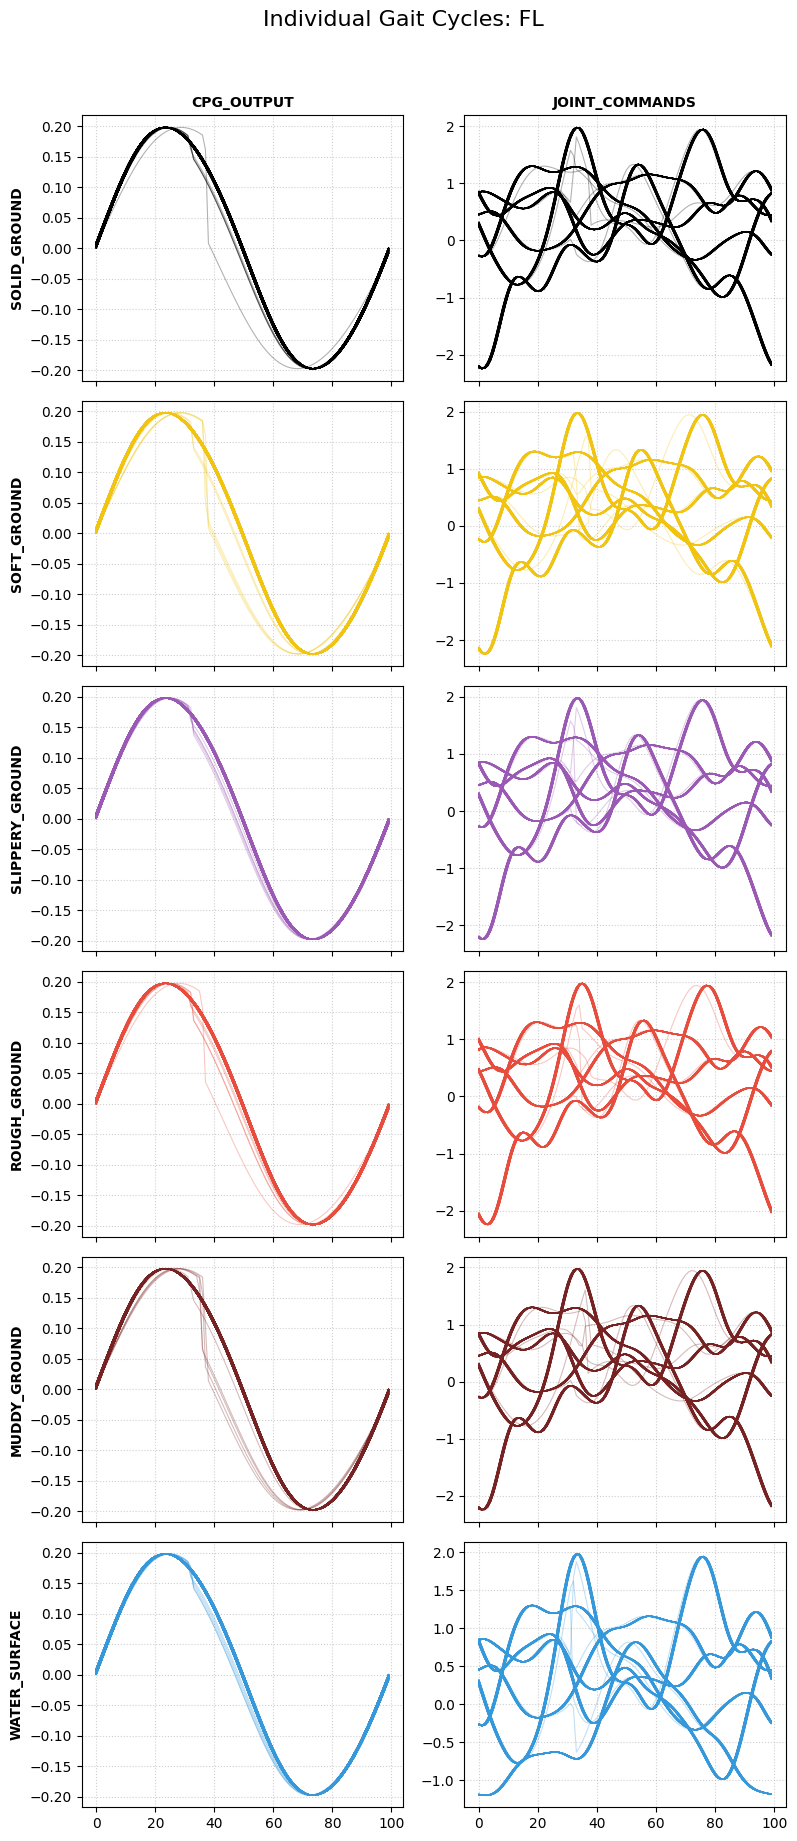

In [7]:

def plot_all_individual_cycles(cycle_results, sensor_list, leg_idx=0):
    """
    Plots every single cycle for every terrain to see the raw distribution.
    """
    terrains = list(cycle_results.keys())
    num_terrains = len(terrains)
    num_sensors = len(sensor_list)
    
    colors = {
        'solid_ground': "#000000", 'rough_ground': '#e74c3c', 'water_surface': '#3498db', 
        'soft_ground': '#f1c40f', 'muddy_ground': "#772222", 'slippery_ground': '#9b59b6'
    }

    # Use a dynamic title based on the index
    # We try to find the name from the global scope, otherwise use the index number
    try:
        # Check if the first sensor in the list is a leg or joint sensor
        is_joint = 'joint' in sensor_list[0]
        feature_name = name_joints[leg_idx] if is_joint else name_legs[leg_idx]
    except (NameError, IndexError):
        feature_name = f"Index {leg_idx}"

    fig, axes = plt.subplots(num_terrains, num_sensors, 
                               figsize=(4 * num_sensors, 3 * num_terrains), 
                               sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

    for t_idx, terrain in enumerate(terrains):
        for s_idx, sensor in enumerate(sensor_list):
            ax = axes[t_idx, s_idx]
            
            # Use .get() to avoid KeyError if a sensor is missing for a terrain
            cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
            if not cycles or len(cycles) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue
            
            color = colors.get(terrain, 'black')
            
            # Plot every single cycle
            for cycle in cycles:
                # cycle shape is (100, num_features)
                ax.plot(cycle[:, leg_idx], color=color, alpha=0.3, linewidth=0.8)
            
            # Formatting titles only for the top row
            if t_idx == 0:
                ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
            # Formatting labels only for the first column
            if s_idx == 0:
                ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execution ---
# sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
# sensors_to_plot = ['cpg_output', 'foot_force', 'joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb']
sensors_to_plot = ['cpg_output', 'joint_commands']
plot_all_individual_cycles(processed_cycle_results, sensors_to_plot, leg_idx=2)

In [8]:
import numpy as np

def export_cycles_to_npz(cycle_results, filename='processed_gait_cycles.npz'):
    """
    Exports nested gait cycle dictionary to a flattened .npz file.
    Example key: 'rough_joint_angle_fb'
    """
    export_dict = {}
    
    for terrain, sensors in cycle_results.items():
        # terrain = terrain.replace("_ground", "")
        for sensor_name, cycles_list in sensors.items():
            if cycles_list:
                # Convert list of cycles to a single (N, 100, features) array
                data_array = np.stack(cycles_list)
                # Create a flattened key string
                key = f"{terrain}_{sensor_name}"
                export_dict[key] = data_array
    
    # Save using keyword arguments
    np.savez_compressed(filename, **export_dict)
    print(f"Successfully exported {len(export_dict)} datasets to {filename}")

# --- Execution ---
export_cycles_to_npz(processed_cycle_results, 'walking_terrain_datasets.npz')

Successfully exported 72 datasets to walking_terrain_datasets.npz


In [9]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_all_individual_cycles(cycle_results, sensor_list, leg_idx=0):
#     """
#     Plots every single cycle for every terrain to see the raw distribution.
#     """
#     terrains = list(cycle_results.keys())
#     num_terrains = len(terrains)
#     num_sensors = len(sensor_list)
    
#     colors = {
#         'solid_ground': "#000000", 'rough_ground': '#e74c3c', 'water_surface': '#3498db', 
#         'soft_ground': '#f1c40f', 'muddy_ground': "#772222", 'slippery_ground': '#9b59b6'
#     }

#     # Use a dynamic title based on the index
#     # We try to find the name from the global scope, otherwise use the index number
#     try:
#         # Check if the first sensor in the list is a leg or joint sensor
#         is_joint = 'joint' in sensor_list[0]
#         feature_name = name_joints[leg_idx] if is_joint else name_legs[leg_idx]
#     except (NameError, IndexError):
#         feature_name = f"Index {leg_idx}"

#     fig, axes = plt.subplots(num_terrains, num_sensors, 
#                                figsize=(4 * num_sensors, 3 * num_terrains), 
#                                sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

#     for t_idx, terrain in enumerate(terrains):
#         for s_idx, sensor in enumerate(sensor_list):
#             ax = axes[t_idx, s_idx]
            
#             # Use .get() to avoid KeyError if a sensor is missing for a terrain
#             cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
#             if not cycles or len(cycles) == 0:
#                 ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
#                 continue
            
#             color = colors.get(terrain, 'black')
            
#             # Plot every single cycle
#             for cycle in cycles:
#                 # cycle shape is (100, num_features)
#                 ax.plot(cycle[:, leg_idx], color=color, alpha=0.3, linewidth=0.8)
            
#             # Formatting titles only for the top row
#             if t_idx == 0:
#                 ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
#             # Formatting labels only for the first column
#             if s_idx == 0:
#                 ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
#             ax.grid(True, linestyle=':', alpha=0.6)

#     plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
#     plt.tight_layout()
#     plt.show()

# # --- Execution ---
# # sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
# sensors_to_plot = ['cpg_output', 'foot_force', 'joint_stiffness_fb', 'joint_damping_fb', 'leg_torque_feedforward']
# plot_all_individual_cycles(processed_cycle_results, sensors_to_plot, leg_idx=2)

## plotly check cycle

In [10]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
# import numpy as np

# def plot_all_individual_cycles_plotly(cycle_results, sensor_list, feature_idx=0):
# 	"""
# 	Plots every single cycle for every terrain using Plotly for interactivity.
# 	"""
# 	terrains = list(cycle_results.keys())
# 	num_terrains = len(terrains)
# 	num_sensors = len(sensor_list)
	
# 	# Professional color palette
# 	colors = {
# 		'flat': '#2ecc71', 'rough': '#e74c3c', 'sponge': '#3498db', 
# 		'sandy': '#f1c40f', 'muddy': '#9b59b6'
# 	}

# 	# Create subplot grid
# 	fig = make_subplots(
# 		rows=num_terrains, 
# 		cols=num_sensors,
# 		row_titles=[t.upper() for t in terrains],
# 		column_titles=[s.upper().replace('_', ' ') for s in sensor_list],
# 		shared_xaxes=True,
# 		vertical_spacing=0.05,
# 		horizontal_spacing=0.03
# 	)

# 	for t_idx, terrain in enumerate(terrains):
# 		color = colors.get(terrain, '#636EFA')
		
# 		for s_idx, sensor in enumerate(sensor_list):
# 			cycles = cycle_results[terrain].get(sensor, [])
			
# 			if not cycles:
# 				continue
			
# 			# Plot each cycle
# 			for c_idx, cycle in enumerate(cycles):
# 				fig.add_trace(
# 					go.Scatter(
# 						x=np.arange(100),
# 						y=cycle[:, feature_idx],
# 						mode='lines',
# 						line=dict(color=color, width=1),
# 						opacity=0.2,
# 						name=f"{terrain}_cycle_{c_idx}",
# 						showlegend=False, # Hide individual cycles from legend to avoid clutter
# 					),
# 					row=t_idx + 1,
# 					col=s_idx + 1
# 				)

# 	# Update layout for a clean, academic look
# 	fig.update_layout(
# 		height=300 * num_terrains,
# 		width=350 * num_sensors,
# 		title_text=f"Individual Gait Cycles (Feature Index: {feature_idx})",
# 		template="plotly_white",
# 		showlegend=False
# 	)

# 	# Add X-axis label to the bottom row only
# 	fig.update_xaxes(title_text="Gait Cycle (%)", row=num_terrains)
	
# 	fig.show()

# # --- Execution ---
# sensors_to_plot = [
# 	# 'cpg_output', 
# 	'foot_force', 
# 	'leg_stiffness', 
# 	'leg_damping', 
# 	'joint_torque_fb' # Adjusted name to match your previous config
# ]

# plot_all_individual_cycles_plotly(processed_cycle_results, sensors_to_plot, feature_idx=0)

## Plot comparison

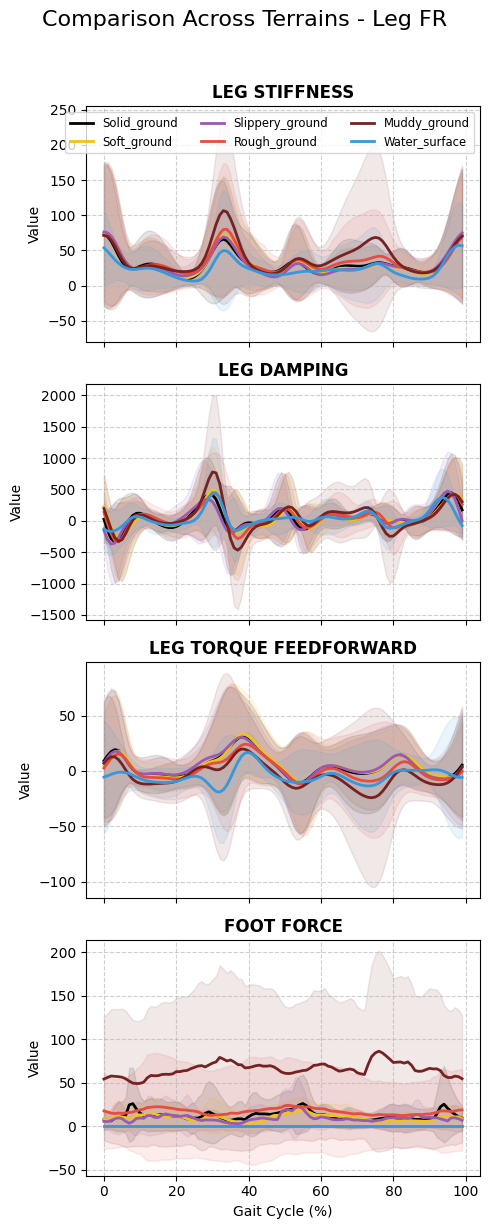

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_sensors_comparison(cycle_results, sensor_list, feature_index=0, feature_name="Leg 0"):
    """
    Creates a vertical stack of subplots comparing multiple sensors across all terrains.
    """
    terrains = list(cycle_results.keys())
    colors = {
            'solid_ground': "#000000", 'rough_ground': '#e74c3c', 'water_surface': '#3498db', 
            'soft_ground': '#f1c40f', 'muddy_ground': "#772222", 'slippery_ground': '#9b59b6'
        }
    
    num_sensors = len(sensor_list)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(5, 3 * num_sensors), sharex=True)
    
    # Ensure axes is iterable even if there's only one sensor
    if num_sensors == 1:
        axes = [axes]

    for i, sensor_name in enumerate(sensor_list):
        ax = axes[i]
        
        for terrain in terrains:
            # Check if data exists for this terrain/sensor combo
            cycles = cycle_results.get(terrain, {}).get(sensor_name, [])
            if not cycles:
                continue
                
            data_stack = np.stack(cycles)
            feature_data = data_stack[:, :, feature_index]
            
            mean_traj = np.mean(feature_data, axis=0)
            std_traj = np.std(feature_data, axis=0)
            
            x = np.arange(100)
            color = colors.get(terrain, 'black')
            
            ax.plot(x, mean_traj, label=terrain.capitalize(), color=color, linewidth=2)
            ax.fill_between(x, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.1)

        ax.set_ylabel("Value")
        ax.set_title(f"{sensor_name.replace('_', ' ').upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only put the legend on the top plot to keep it clean
        if i == 0:
            ax.legend(loc='upper right', ncol=3, fontsize='small')

    plt.xlabel("Gait Cycle (%)")
    plt.suptitle(f"Comparison Across Terrains - {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("terrain_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()


# --- Execution ---
sensors_to_compare = [
    # 'cpg_output', 
    'leg_stiffness', 
    'leg_damping', 
    'leg_torque_feedforward', 
    'foot_force'
]

# Run the subplot function
plot_all_sensors_comparison(
    processed_cycle_results, 
    sensors_to_compare, 
    feature_index=0, 
    feature_name=f"Leg {name_legs[0]}"
)

